In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:

!ls "/content/drive/MyDrive/DL_Project_Gait/data/"

'HuGaDB v2.zip'


In [5]:

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU device: Tesla T4


In [6]:

!mkdir -p /content/hugadb
!unzip -q "/content/drive/MyDrive/DL_Project_Gait/data/HuGaDB v2.zip" -d /content/hugadb/

print("Files extracted:")
!ls /content/hugadb/ | head -20
print("...")
print("\nTotal files:")
!ls /content/hugadb/ | wc -l

Files extracted:
HuGaDB_v2_various_01_00.txt
HuGaDB_v2_various_01_01.txt
HuGaDB_v2_various_01_02.txt
HuGaDB_v2_various_01_03.txt
HuGaDB_v2_various_01_04.txt
HuGaDB_v2_various_01_05.txt
HuGaDB_v2_various_01_06.txt
HuGaDB_v2_various_01_07.txt
HuGaDB_v2_various_01_08.txt
HuGaDB_v2_various_01_09.txt
HuGaDB_v2_various_01_10.txt
HuGaDB_v2_various_01_11.txt
HuGaDB_v2_various_01_12.txt
HuGaDB_v2_various_01_13.txt
HuGaDB_v2_various_01_14.txt
HuGaDB_v2_various_01_15.txt
HuGaDB_v2_various_01_16.txt
HuGaDB_v2_various_02_00.txt
HuGaDB_v2_various_02_01.txt
HuGaDB_v2_various_02_02.txt
...

Total files:
364


In [7]:

print("=== First 10 lines of HuGaDB_v2_various_01_00.txt ===\n")
!head -n 10 "/content/hugadb/HuGaDB_v2_various_01_00.txt"

=== First 10 lines of HuGaDB_v2_various_01_00.txt ===

#Activity	sitting standing_up standing sitting_down sitting standing_up standing sitting_down sitting standing_up standing sitting_down sitting standing_up standing sitting_down sitting 
#ActivityID	5 7 8 6 5 7 8 6 5 7 8 6 5 7 8 6 5 
#Date 10-26-17-47
acc_rf_x	acc_rf_y	acc_rf_z	gyro_rf_x	gyro_rf_y	gyro_rf_z	acc_rs_x	acc_rs_y	acc_rs_z	gyro_rs_x	gyro_rs_y	gyro_rs_z	acc_rt_x	acc_rt_y	acc_rt_z	gyro_rt_x	gyro_rt_y	gyro_rt_z	acc_lf_x	acc_lf_y	acc_lf_z	gyro_lf_x	gyro_lf_y	gyro_lf_z	acc_ls_x	acc_ls_y	acc_ls_z	gyro_ls_x	gyro_ls_y	gyro_ls_z	acc_lt_x	acc_lt_y	acc_lt_z	gyro_lt_x	gyro_lt_y	gyro_lt_z	EMG_r	EMG_l	act
-7684	-1200	13444	16	11	-22	-14464	520	-7480	-6	-2	22	-6528	-1016	15256	35	-7	-6	-6912	5720	13824	34	-7	-22	-15176	408	-7168	12	-24	38	-6064	968	15960	37	-10	-21	120	127	5
-7712	-1140	13520	21	10	-19	-14360	400	-7776	11	5	28	-6536	-920	15344	47	-10	-7	-6952	5608	13888	40	-16	-14	-15296	344	-7048	26	-24	44	-5872	1128	15904	42	-9	-25	1

In [8]:
import pandas as pd
import numpy as np
import os
sample_file = "/content/hugadb/HuGaDB_v2_various_01_00.txt"
df = pd.read_csv(sample_file, sep='\t', skiprows=3)


print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Shape: (3142, 39)
Columns (39):
['acc_rf_x', 'acc_rf_y', 'acc_rf_z', 'gyro_rf_x', 'gyro_rf_y', 'gyro_rf_z', 'acc_rs_x', 'acc_rs_y', 'acc_rs_z', 'gyro_rs_x', 'gyro_rs_y', 'gyro_rs_z', 'acc_rt_x', 'acc_rt_y', 'acc_rt_z', 'gyro_rt_x', 'gyro_rt_y', 'gyro_rt_z', 'acc_lf_x', 'acc_lf_y', 'acc_lf_z', 'gyro_lf_x', 'gyro_lf_y', 'gyro_lf_z', 'acc_ls_x', 'acc_ls_y', 'acc_ls_z', 'gyro_ls_x', 'gyro_ls_y', 'gyro_ls_z', 'acc_lt_x', 'acc_lt_y', 'acc_lt_z', 'gyro_lt_x', 'gyro_lt_y', 'gyro_lt_z', 'EMG_r', 'EMG_l', 'act']

First 5 rows:


,acc_rf_x,acc_rf_y,acc_rf_z,gyro_rf_x,gyro_rf_y,gyro_rf_z,acc_rs_x,acc_rs_y,acc_rs_z,gyro_rs_x,...,gyro_ls_z,acc_lt_x,acc_lt_y,acc_lt_z,gyro_lt_x,gyro_lt_y,gyro_lt_z,EMG_r,EMG_l,act
0,-7684,-1200,13444,16,11,-22,-14464,520,-7480,-6,...,38,-6064,968,15960,37,-10,-21,120,127,5
1,-7712,-1140,13520,21,10,-19,-14360,400,-7776,11,...,44,-5872,1128,15904,42,-9,-25,120,127,5
2,-7728,-1084,13468,23,8,-20,-14376,592,-7264,25,...,48,-5720,904,16120,45,-14,-35,120,128,5
3,-7692,-1056,13456,20,10,-23,-14440,624,-7368,33,...,50,-5632,1024,16168,44,-18,-38,120,128,5
4,-7716,-1084,13512,20,8,-25,-14504,640,-7416,33,...,50,-5576,1096,16304,55,-14,-33,120,127,5


In [9]:

activity_names = {
    1: 'walking', 2: 'running', 3: 'going_up', 4: 'going_down',
    5: 'sitting', 6: 'sitting_down', 7: 'standing_up', 8: 'standing',
    9: 'bicycling', 10: 'up_by_elevator', 11: 'down_by_elevator',
    12: 'sitting_in_car'
}

print("Activity distribution in this file:")
activity_counts = df['act'].value_counts().sort_index()
for act_id, count in activity_counts.items():
    name = activity_names.get(act_id, f'unknown_{act_id}')
    print(f"  {act_id} ({name}): {count} samples")

print(f"\nTotal samples: {len(df)}")
print(f"At ~60Hz, that's {len(df)/60:.1f} seconds of data")

Activity distribution in this file:
  5 (sitting): 1192 samples
  6 (sitting_down): 431 samples
  7 (standing_up): 459 samples
  8 (standing): 1060 samples

Total samples: 3142
At ~60Hz, that's 52.4 seconds of data


In [11]:
# List all walking files to see actual naming
import os
all_files = os.listdir('/content/hugadb/')
walking_files = [f for f in all_files if 'walking' in f]
print(f"Total walking files: {len(walking_files)}")
print("\nFirst 10 walking files:")
for f in sorted(walking_files)[:10]:
    print(f"  {f}")

Total walking files: 0

First 10 walking files:


In [12]:
# Check what activity types appear in filenames
all_files = os.listdir('/content/hugadb/')
print(f"Total files: {len(all_files)}")

# Extract the activity portion of filenames
activities_in_filenames = set()
for f in all_files:
    if f.startswith('HuGaDB_v2_'):
        # Strip prefix and the participant/counter suffix
        parts = f.replace('HuGaDB_v2_', '').rsplit('_', 2)
        if len(parts) >= 1:
            activities_in_filenames.add(parts[0])

print(f"\nUnique activity types in filenames: {len(activities_in_filenames)}")
for a in sorted(activities_in_filenames):
    count = sum(1 for f in all_files if f.startswith(f'HuGaDB_v2_{a}_'))
    print(f"  {a}: {count} files")

Total files: 364

Unique activity types in filenames: 1
  various: 364 files


In [13]:
# Find files that contain walking activity (act = 1)
files_with_walking = []
for filename in sorted(os.listdir('/content/hugadb/')):
    filepath = f'/content/hugadb/{filename}'
    try:
        df_check = pd.read_csv(filepath, sep='\t', skiprows=3)
        if 1 in df_check['act'].unique():
            files_with_walking.append(filename)
    except:
        continue

print(f"Files containing walking: {len(files_with_walking)}")
print(f"\nFirst 5: {files_with_walking[:5]}")

Files containing walking: 229

First 5: ['HuGaDB_v2_various_01_04.txt', 'HuGaDB_v2_various_01_05.txt', 'HuGaDB_v2_various_01_06.txt', 'HuGaDB_v2_various_01_07.txt', 'HuGaDB_v2_various_01_08.txt']


Loaded: HuGaDB_v2_various_01_04.txt
Shape: (4427, 39)
Activities in this file: [8 4 1]
Walking samples in this file: 2875


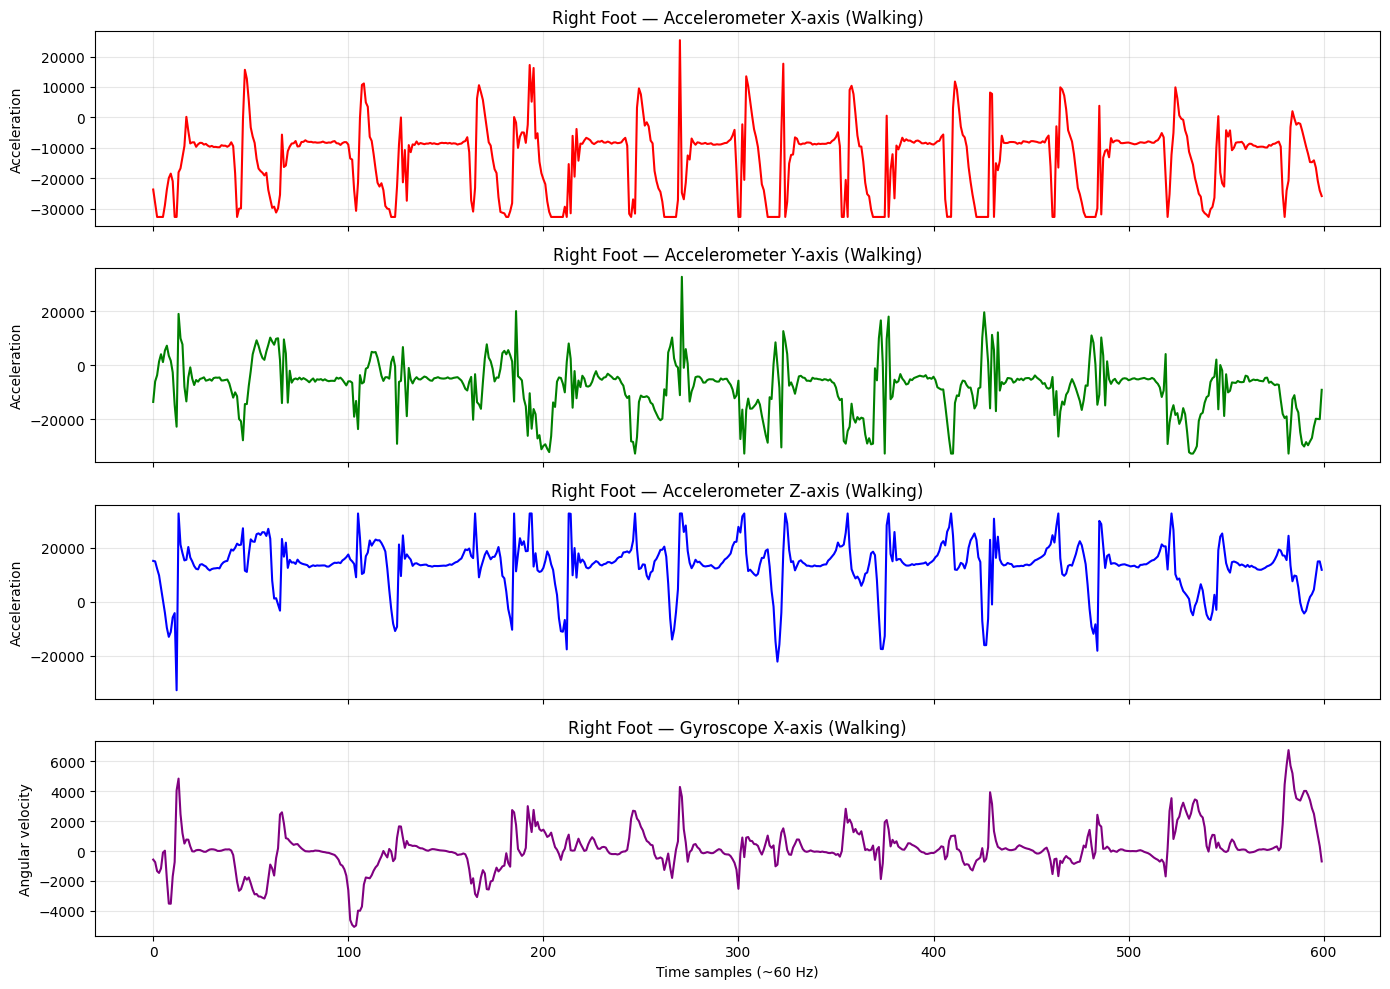


✓ Plot saved!


In [14]:
import matplotlib.pyplot as plt

# Load the first file containing walking
walking_file = f'/content/hugadb/{files_with_walking[0]}'
df_walk = pd.read_csv(walking_file, sep='\t', skiprows=3)
print(f"Loaded: {files_with_walking[0]}")
print(f"Shape: {df_walk.shape}")
print(f"Activities in this file: {df_walk['act'].unique()}")

# Get only the walking portion
walking_only = df_walk[df_walk['act'] == 1].reset_index(drop=True)
print(f"Walking samples in this file: {len(walking_only)}")

# Plot 4 sensor signals from the walking section
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

n_samples = min(600, len(walking_only))

axes[0].plot(walking_only['acc_rf_x'][:n_samples], color='red')
axes[0].set_title('Right Foot — Accelerometer X-axis (Walking)', fontsize=12)
axes[0].set_ylabel('Acceleration')
axes[0].grid(alpha=0.3)

axes[1].plot(walking_only['acc_rf_y'][:n_samples], color='green')
axes[1].set_title('Right Foot — Accelerometer Y-axis (Walking)', fontsize=12)
axes[1].set_ylabel('Acceleration')
axes[1].grid(alpha=0.3)

axes[2].plot(walking_only['acc_rf_z'][:n_samples], color='blue')
axes[2].set_title('Right Foot — Accelerometer Z-axis (Walking)', fontsize=12)
axes[2].set_ylabel('Acceleration')
axes[2].grid(alpha=0.3)

axes[3].plot(walking_only['gyro_rf_x'][:n_samples], color='purple')
axes[3].set_title('Right Foot — Gyroscope X-axis (Walking)', fontsize=12)
axes[3].set_ylabel('Angular velocity')
axes[3].set_xlabel('Time samples (~60 Hz)')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/raw_signals_walking.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Plot saved!")

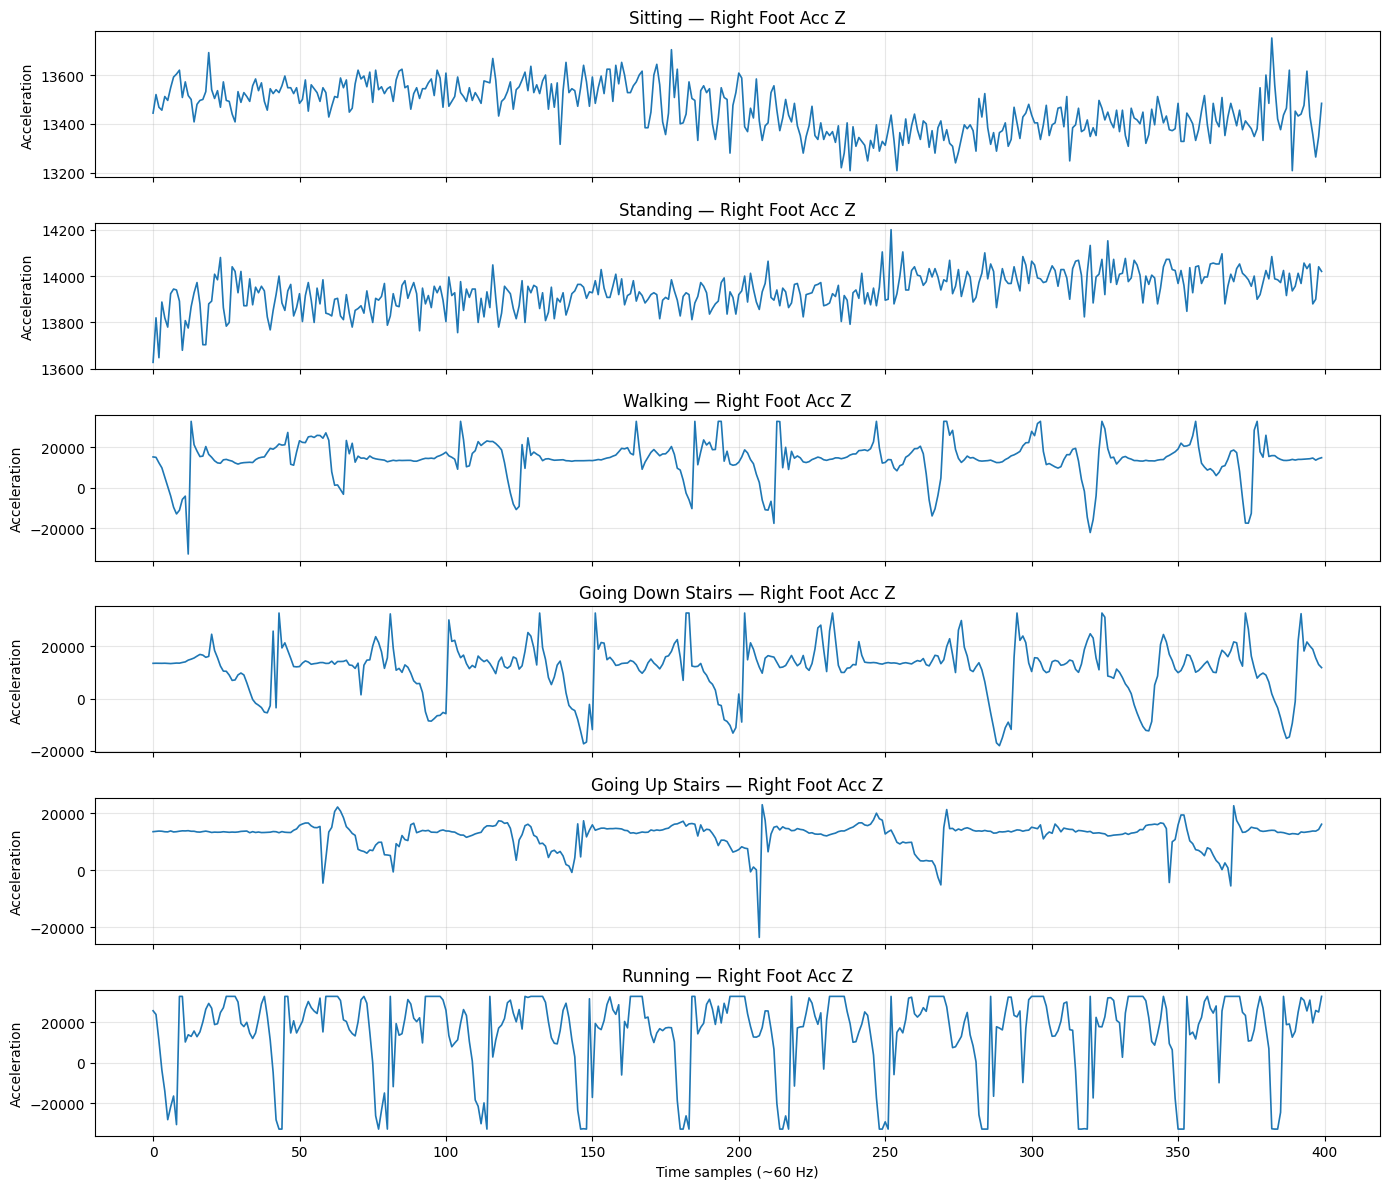


✓ Activity comparison plot saved!
Activities found and plotted: ['Sitting', 'Standing', 'Walking', 'Going Down Stairs', 'Going Up Stairs', 'Running']


In [15]:
# For each activity, find a file that contains it and plot it
activity_names = {
    1: 'Walking', 2: 'Running', 3: 'Going Up Stairs', 4: 'Going Down Stairs',
    5: 'Sitting', 8: 'Standing'
}

# Find one file per activity that has substantial samples
samples_per_activity = {}
for filename in sorted(os.listdir('/content/hugadb/'))[:50]:  # check first 50 files
    filepath = f'/content/hugadb/{filename}'
    try:
        df_check = pd.read_csv(filepath, sep='\t', skiprows=3)
        for act_id in activity_names:
            if act_id not in samples_per_activity:
                act_samples = df_check[df_check['act'] == act_id]
                if len(act_samples) >= 400:
                    samples_per_activity[act_id] = act_samples['acc_rf_z'].values[:400]
    except:
        continue
    if len(samples_per_activity) == len(activity_names):
        break

# Plot comparison
fig, axes = plt.subplots(len(samples_per_activity), 1, figsize=(14, 12), sharex=True)

for idx, (act_id, signal) in enumerate(samples_per_activity.items()):
    axes[idx].plot(signal, linewidth=1.2)
    axes[idx].set_title(f'{activity_names[act_id]} — Right Foot Acc Z', fontsize=12)
    axes[idx].set_ylabel('Acceleration')
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel('Time samples (~60 Hz)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/activity_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Activity comparison plot saved!")
print(f"Activities found and plotted: {[activity_names[a] for a in samples_per_activity]}")

In [16]:
import time
from tqdm import tqdm

# Define the columns we'll use (skip EMG, just use IMU)
# 36 IMU columns: 6 sensors × 6 features each (3 acc + 3 gyro)
sensor_columns = [
    'acc_rf_x', 'acc_rf_y', 'acc_rf_z', 'gyro_rf_x', 'gyro_rf_y', 'gyro_rf_z',  # right foot
    'acc_rs_x', 'acc_rs_y', 'acc_rs_z', 'gyro_rs_x', 'gyro_rs_y', 'gyro_rs_z',  # right shin
    'acc_rt_x', 'acc_rt_y', 'acc_rt_z', 'gyro_rt_x', 'gyro_rt_y', 'gyro_rt_z',  # right thigh
    'acc_lf_x', 'acc_lf_y', 'acc_lf_z', 'gyro_lf_x', 'gyro_lf_y', 'gyro_lf_z',  # left foot
    'acc_ls_x', 'acc_ls_y', 'acc_ls_z', 'gyro_ls_x', 'gyro_ls_y', 'gyro_ls_z',  # left shin
    'acc_lt_x', 'acc_lt_y', 'acc_lt_z', 'gyro_lt_x', 'gyro_lt_y', 'gyro_lt_z',  # left thigh
]

print(f"Number of sensor columns: {len(sensor_columns)}")

def load_hugadb_file(filepath):
    """Load a single HuGaDB file and extract participant ID from filename."""
    df = pd.read_csv(filepath, sep='\t', skiprows=3)
    # Extract participant ID from filename: HuGaDB_v2_various_XX_YY.txt -> XX
    filename = os.path.basename(filepath)
    parts = filename.replace('.txt', '').split('_')
    participant_id = int(parts[3])  # the XX part
    return df, participant_id

# Load all files
all_data = []
all_labels = []
all_participants = []

print("\nLoading all 364 files...")
start = time.time()

for filename in tqdm(sorted(os.listdir('/content/hugadb/'))):
    filepath = f'/content/hugadb/{filename}'
    try:
        df, participant_id = load_hugadb_file(filepath)
        # Verify expected columns exist
        if not all(col in df.columns for col in sensor_columns + ['act']):
            continue
        # Extract sensor data and labels
        sensor_data = df[sensor_columns].values  # shape: (n_samples, 36)
        labels = df['act'].values                # shape: (n_samples,)

        all_data.append(sensor_data)
        all_labels.append(labels)
        all_participants.append(np.full(len(df), participant_id))
    except Exception as e:
        print(f"Skipping {filename}: {e}")
        continue

# Concatenate everything
X_all = np.vstack(all_data)
y_all = np.concatenate(all_labels)
p_all = np.concatenate(all_participants)

elapsed = time.time() - start
print(f"\n✓ Loaded in {elapsed:.1f} seconds")
print(f"\nTotal samples: {len(X_all):,}")
print(f"Sensor data shape: {X_all.shape}")
print(f"Labels shape: {y_all.shape}")
print(f"Unique participants: {sorted(np.unique(p_all))}")
print(f"Unique activities: {sorted(np.unique(y_all))}")

Number of sensor columns: 36

Loading all 364 files...


100%|██████████| 364/364 [00:05<00:00, 68.97it/s]



✓ Loaded in 5.4 seconds

Total samples: 1,137,986
Sensor data shape: (1137986, 36)
Labels shape: (1137986,)
Unique participants: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Unique activities: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11)]


Class distribution across all data:
------------------------------------------------------------
   1 walking                 314,966 (27.68%) █████████████
   2 running                  65,917 ( 5.79%) ██
   3 going_up                135,127 (11.87%) █████
   4 going_down              119,819 (10.53%) █████
   5 sitting                  82,819 ( 7.28%) ███
   6 sitting_down             18,180 ( 1.60%) 
   7 standing_up              20,603 ( 1.81%) 
   8 standing                222,649 (19.57%) █████████
  10 up_by_elevator           89,144 ( 7.83%) ███
  11 down_by_elevator         68,762 ( 6.04%) ███
------------------------------------------------------------
  Total samples: 1,137,986


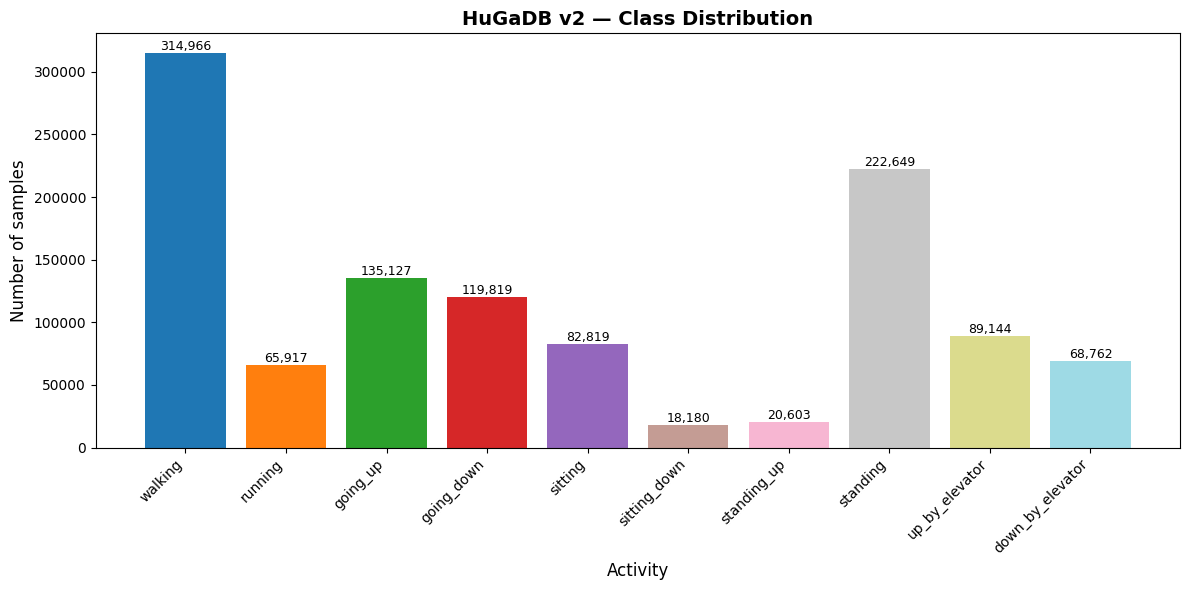


✓ Class distribution plot saved!


In [17]:
# Class distribution analysis
activity_names = {
    1: 'walking', 2: 'running', 3: 'going_up', 4: 'going_down',
    5: 'sitting', 6: 'sitting_down', 7: 'standing_up', 8: 'standing',
    9: 'bicycling', 10: 'up_by_elevator', 11: 'down_by_elevator',
    12: 'sitting_in_car'
}

print("Class distribution across all data:")
print("-" * 60)
unique, counts = np.unique(y_all, return_counts=True)
total = len(y_all)

for act_id, count in zip(unique, counts):
    name = activity_names.get(act_id, f'unknown_{act_id}')
    pct = 100 * count / total
    bar = '█' * int(pct / 2)
    print(f"  {act_id:2d} {name:20s} {count:>10,} ({pct:5.2f}%) {bar}")

print("-" * 60)
print(f"  Total samples: {total:,}")

# Plot it
fig, ax = plt.subplots(figsize=(12, 6))
names = [activity_names.get(a, str(a)) for a in unique]
colors = plt.cm.tab20(np.linspace(0, 1, len(unique)))
bars = ax.bar(names, counts, color=colors)

ax.set_xlabel('Activity', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('HuGaDB v2 — Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add value labels on top
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DL_Project_Gait/results/class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Class distribution plot saved!")

In [18]:
# Save processed arrays to Drive for quick reloading later
save_dir = '/content/drive/MyDrive/DL_Project_Gait/data/processed'
os.makedirs(save_dir, exist_ok=True)

print("Saving master dataset to Drive...")
np.save(f'{save_dir}/X_all.npy', X_all)
np.save(f'{save_dir}/y_all.npy', y_all)
np.save(f'{save_dir}/p_all.npy', p_all)

print("✓ Saved!")
print(f"\nFiles saved to: {save_dir}")
print(f"  X_all.npy   ({X_all.nbytes / 1e6:.1f} MB)")
print(f"  y_all.npy   ({y_all.nbytes / 1e6:.1f} MB)")
print(f"  p_all.npy   ({p_all.nbytes / 1e6:.1f} MB)")

Saving master dataset to Drive...
✓ Saved!

Files saved to: /content/drive/MyDrive/DL_Project_Gait/data/processed
  X_all.npy   (327.7 MB)
  y_all.npy   (9.1 MB)
  p_all.npy   (9.1 MB)
